# Retina-like RFs and their mosaic organization

This notebook generates the plots for Figure 3. All plots use the retinal model trained for prediction. The pre-trained model can either be downloaded from this repo or can be trained from scatch (see README).

In [2]:
import os

import torch
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse, Rectangle, ConnectionPatch, Circle
import seaborn as sns

from brainbox import tuning
from retina import train, analysis

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "Arial"

%reload_ext autoreload
%autoreload 2

/home/nicolharper/miniconda3/envs/retina/lib/python3.8/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [24]:
root = os.path.expanduser("~/Documents/LukeCodeOrig/RetinalModel-main")

In [4]:
model = train.Trainer.load_model(f"{root}/results", "0.0031622776601683794_*_0.01_0.6_128_8")


/home/nicolharper/miniconda3/envs/retina/lib/python3.8/site-packages/devtorch/query.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(mod

In [5]:
torch.manual_seed(0)
rf_query = analysis.RFQuery(root, model)

INFO:util:Processing batch 0 out of 4...
INFO:util:Processing batch 1 out of 4...
INFO:util:Processing batch 2 out of 4...
INFO:util:Processing batch 3 out of 4...
INFO:gaussian:CC criteria exclusion 219
INFO:gaussian:Location criteria exclusion 38
INFO:gaussian:Envelope criteria exclusion 12


## Cell types

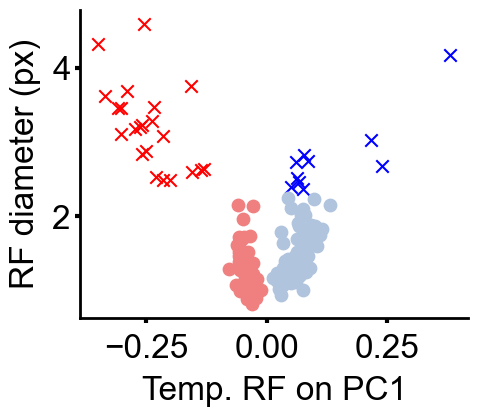

In [6]:
def plot_cell_types(ax):
    for i in range(4):
        query = rf_query.params_df["type"] == i
        ax.scatter(rf_query.params_df[query]["first_pc"], rf_query.params_df[query]["size"], s=80, marker=cell_type_marks[i], c=cell_type_colors_map[i])
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    labelsize = 24
    ax.xaxis.set_tick_params(width=3, labelsize=labelsize, pad=8)
    ax.yaxis.set_tick_params(width=3, labelsize=labelsize)
    ax.set_xlabel("Temp. RF on PC1", fontsize=labelsize, labelpad=8)
    ax.set_ylabel("RF diameter (px)", fontsize=labelsize, labelpad=8)

cell_type_colors_map = {0: "red", 2: "lightcoral", 1: "blue", 3: "lightsteelblue"}
cell_type_marks = ["x", "x", "o", "o"]
cell_type_colors = [cell_type_colors_map[i] for i in rf_query.params_df["type"]]
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
plot_cell_types(ax)
# top left: parasol on
# top right: parasol off
# bottom left: midget on
# bottom right: midget off
# 0: on parasol
# 1: off parasol
# 2: on midget
# 3: off midget
plt.savefig(f"{root}/figures/fig3/PC_dots.svg", format="svg", transparent=False, bbox_inches="tight")

#Why are there only 4 off parasol rather than 8?

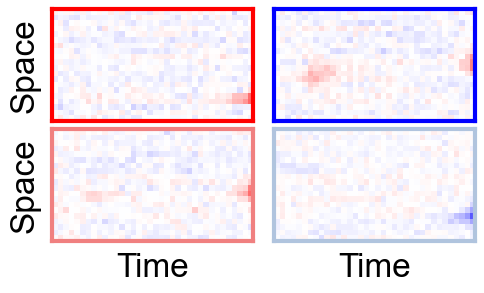

In [7]:
def plot_rf2d(i, c, ax):
    rf2d = rf_query.strfs[i].mean(2).T
    max_v = 0.5
    ax.imshow(rf2d, vmin=-max_v, vmax=max_v, cmap="bwr")
    for ax_name in ["left", "right", "bottom", "top"]:
        ax.spines[ax_name].set_linewidth(3)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(c)
    
fig, axs = plt.subplots(2, 2, figsize=(5, 3))
plot_rf2d(7, "red", axs[0, 0])
plot_rf2d(21, "blue", axs[0, 1])
plot_rf2d(0, "lightcoral", axs[1, 0])
plot_rf2d(1, "lightsteelblue", axs[1, 1])
labelsize = 24
axs[1, 0].set_xlabel("Time", fontsize=labelsize, labelpad=8)
axs[1, 1].set_xlabel("Time", fontsize=labelsize, labelpad=8)
axs[0, 0].set_ylabel("Space", fontsize=labelsize, labelpad=8)
axs[1, 0].set_ylabel("Space", fontsize=labelsize, labelpad=8)
fig.tight_layout()
plt.savefig(f"{root}/figures/fig3/rf2d.svg", format="svg", transparent=False, bbox_inches="tight")

## Parasol- and midget-like units & light response

In [8]:
pre_ms = 400
light_ms = 800
flash_query = analysis.FlashQuery(model, pre_ms=pre_ms, light_ms=light_ms, off_ms=light_ms, lum=0.5, model_n_frames=29)

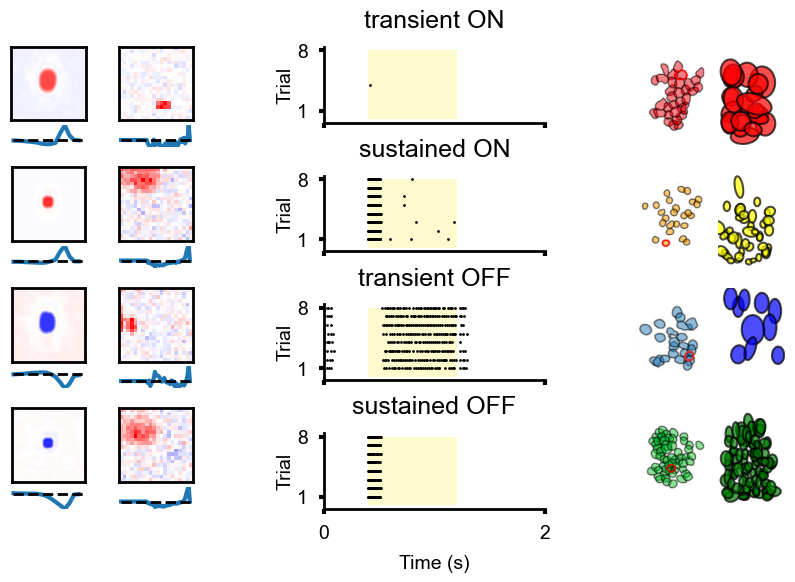

In [9]:
def to_grayscale(img):
    img = np.dot(img[..., :3], [0.299, 0.587, 0.114])
    img = (img - img.mean()) / img.max()
    
    return img

def plot_rf(rf, title, ax):
    if type(rf) == torch.Tensor:
        v = rf.abs().max()
    else:
        v = 1
    
    ax.imshow(rf, cmap="bwr", vmin=-v, vmax=v)
    ax.set_title(title, fontsize=18, pad=8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines["top"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    ax.spines["right"].set_linewidth(2)
    
def plot_temp_profile(profile, ax):
    ax.plot(profile/profile.abs().max(), linewidth=3)
    ax.plot([0, len(profile)], [0, 0], linestyle="dashed", c="black", linewidth=2)
    ax.set_xticks([])
    ax.set_yticks([])
    
    if profile.max() > -profile.min():
        ax.set_ylim([-0.5, 1])
    else:
        ax.set_ylim([-1, 0.5])
        
    for ax_name in ["top", "bottom", "left", "right"]:
        ax.spines[ax_name].set_visible(False)
    
def plot_all_rf(rf, profile, spec, fig):
    rf_spec = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=spec, height_ratios=[1, 0.3], hspace=0.1)
    rf_ax = plt.Subplot(fig, rf_spec[0])
    profile_ax = plt.Subplot(fig, rf_spec[1])
    fig.add_subplot(rf_ax)
    fig.add_subplot(profile_ax)
    plot_rf(rf, "", rf_ax)
    plot_temp_profile(profile, profile_ax)
    
def plot_light_response(raster_x, raster_y, title, spec, fig):
    ax = plt.Subplot(fig, spec)
    fig.add_subplot(ax)
    ax.set_title(title, fontsize=18, pad=14)
    dt = 1000 / 240
    light_x = pre_ms / dt
    light_w = light_ms / dt
    rect = Rectangle((light_x, 0), light_w, 8, linewidth=1, edgecolor=None, facecolor="lemonchiffon", alpha=1) # lightyellow
    ax.add_patch(rect)
    
    ax.scatter(raster_x, raster_y+1, s=1, c="black")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    ax.xaxis.set_tick_params(width=3, labelsize=14, pad=8)
    ax.yaxis.set_tick_params(width=3, labelsize=14, pad=8)
    ax.set_yticks([1, 8])
    ax.set_xticks([0, 480])
    ax.set_xlim([0, 480])
    ax.set_xticklabels([])
    ax.set_ylabel("Trial", fontsize=14, labelpad=2)
    
    return ax
    
def plot_mosaic(cell_type, color, dx, dy, spec, fig):
    ax = plt.Subplot(fig, spec)
    fig.add_subplot(ax)
    q = rf_query.params_df["type"] == cell_type
    subparams_df = rf_query.params_df[q]
    
    ells = []
    for i in range(len(subparams_df)): #idx,idx+1,1
        x0 = subparams_df.iloc[i]["x0"]
        y0 = 20 - subparams_df.iloc[i]["y0"]
        sigmax = subparams_df.iloc[i]["sigmax"]
        sigmay = subparams_df.iloc[i]["sigmay"]
        p = subparams_df.iloc[i]["p"]
        ells.append(Ellipse(xy=(x0, y0),
                    width=1.5*sigmax, height=1.5*sigmay,
                    angle=-p*45, ec="black", fc="gray", linewidth=1.5))
    
    for e in ells:
        ax.add_artist(e)
        e.set_clip_box(ax.bbox)
        e.set_alpha(0.7)
        e.set_facecolor(color)
    
    ax.set_xlim(0+dx, 20+dx)
    ax.set_ylim(0+dy, 20+dy)
    ax.set_xticks([])
    ax.set_yticks([])
    
    for ax_name in ["left", "right", "bottom", "top"]:
        ax.spines[ax_name].set_visible(False)    
    
    return ax

def plot_macaque_mosaic(image, spec, fig):
    ax = plt.Subplot(fig, spec)
    fig.add_subplot(ax)
    ax.imshow(image)
    ax.set_xticks([])
    ax.set_yticks([])
    for ax_name in ["top", "bottom", "left", "right"]:
        ax.spines[ax_name].set_visible(False) 
    
fig = plt.figure(figsize=(10, 6))
space = 0.25
fig_spec = gridspec.GridSpec(1, 2, wspace=0.4, hspace=0, width_ratios=[0.4, 1])
fig_spec2 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=fig_spec[1], width_ratios=[1.5, 1], wspace=0.5)

rf_spec = gridspec.GridSpecFromSubplotSpec(4, 2, subplot_spec=fig_spec[0], width_ratios=[1, 1], wspace=0.4)
response_spec = gridspec.GridSpecFromSubplotSpec(4, 1, subplot_spec=fig_spec2[0], hspace=0.7)
mosaic_spec = gridspec.GridSpecFromSubplotSpec(4, 2, subplot_spec=fig_spec2[1], width_ratios=[1, 1], wspace=0.2)

on_parasol_idx = 7
on_midget_idx = 11
off_parasol_id = 21
off_midget_id = 6

macaque_on_parasol_rf = -to_grayscale(plt.imread(f"{root}/data/figures/on_parasol.png"))
macaque_on_midget_rf = -to_grayscale(plt.imread(f"{root}/data/figures/on_midget.png"))
macaque_off_parasol_rf = to_grayscale(plt.imread(f"{root}/data/figures/off_parasol.png"))
macaque_off_midget_rf = to_grayscale(plt.imread(f"{root}/data/figures/off_midget.png"))

macaque_on_parasol_profile = torch.from_numpy(pd.read_csv(f"{root}/data/figures/on_parasol_profile.csv", header=None).iloc[:, 1][-15:].values)
macaque_on_midget_profile = torch.from_numpy(pd.read_csv(f"{root}/data/figures/on_midget_profile.csv", header=None).iloc[:, 1][-15:].values + 1.8)
macaque_off_parasol_profile = torch.from_numpy(pd.read_csv(f"{root}/data/figures/off_parasol_profile.csv", header=None).iloc[:, 1][-15:].values + 2.6)
macaque_off_midget_profile = torch.from_numpy(pd.read_csv(f"{root}/data/figures/off_midget_profile.csv", header=None).iloc[:, 1][-15:].values + 4.2)

macaque_on_parasol_mosaic = plt.imread(f"{root}/data/figures/on_parasol_mosaic.png")
macaque_on_midget_mosaic = plt.imread(f"{root}/data/figures/on_midget_mosaic.png")
macaque_off_parasol_mosaic = plt.imread(f"{root}/data/figures/off_parasol_mosaic.png")
macaque_off_midget_mosaic = plt.imread(f"{root}/data/figures/off_midget_mosaic.png")

plot_all_rf(macaque_on_parasol_rf, macaque_on_parasol_profile, rf_spec[0, 0], fig)
plot_all_rf(macaque_on_midget_rf, macaque_on_midget_profile, rf_spec[1, 0], fig)
plot_all_rf(macaque_off_parasol_rf, macaque_off_parasol_profile, rf_spec[2, 0], fig)
plot_all_rf(macaque_off_midget_rf, macaque_off_midget_profile, rf_spec[3, 0], fig)

on_parasol_profile = torch.cat([torch.zeros(23), torch.Tensor([*rf_query.strfs.mean((2, 3))[on_parasol_idx].tolist(), 0])])
on_midget_profile = torch.cat([torch.zeros(23), torch.Tensor([*rf_query.strfs.mean((2, 3))[on_midget_idx].tolist(), 0])])
off_parasol_profile = torch.cat([torch.zeros(23), torch.Tensor([*rf_query.strfs.mean((2, 3))[off_parasol_id].tolist(), 0])])
off_midget_profile = torch.cat([torch.zeros(23), torch.Tensor([*rf_query.strfs.mean((2, 3))[off_midget_id].tolist(), 0])])

plot_all_rf(rf_query.spatial_rfs[on_parasol_idx], on_parasol_profile, rf_spec[0, 1], fig)
plot_all_rf(rf_query.spatial_rfs[on_midget_idx], on_midget_profile, rf_spec[1, 1], fig)
plot_all_rf(rf_query.spatial_rfs[off_parasol_id], off_parasol_profile, rf_spec[2, 1], fig)
plot_all_rf(rf_query.spatial_rfs[off_midget_id], off_midget_profile, rf_spec[3, 1], fig)

plot_light_response(*flash_query.get_spike_points(rf_query.params_df.iloc[on_parasol_idx]["og_index"]), "transient ON", response_spec[0], fig)
plot_light_response(*flash_query.get_spike_points(rf_query.params_df.iloc[on_midget_idx]["og_index"]), "sustained ON", response_spec[1], fig)
plot_light_response(*flash_query.get_spike_points(rf_query.params_df.iloc[off_parasol_id]["og_index"]), "transient OFF", response_spec[2], fig)
ax = plot_light_response(*flash_query.get_spike_points(rf_query.params_df.iloc[off_midget_id]["og_index"]), "sustained OFF", response_spec[3], fig)
ax.set_xticklabels([0, 2])
ax.set_xlabel("Time (s)", fontsize=14, labelpad=8)

plot_macaque_mosaic(macaque_on_parasol_mosaic, mosaic_spec[0, 0], fig)
plot_macaque_mosaic(macaque_on_midget_mosaic, mosaic_spec[1, 0], fig)
plot_macaque_mosaic(macaque_off_parasol_mosaic, mosaic_spec[2, 0], fig)
plot_macaque_mosaic(macaque_off_midget_mosaic, mosaic_spec[3, 0], fig)

plot_mosaic(0, "red", 1, 4, mosaic_spec[0, 1], fig)
plot_mosaic(2, "yellow", 1, 3, mosaic_spec[1, 1], fig)
plot_mosaic(1, "blue", 0, 2, mosaic_spec[2, 1], fig)
plot_mosaic(3, "green", 0, 2, mosaic_spec[3, 1], fig)
plt.savefig(f"{root}/figures/fig3/main.svg", format="svg", transparent=False, bbox_inches="tight")

Sampling fake populations...
hello


<Figure size 640x480 with 0 Axes>

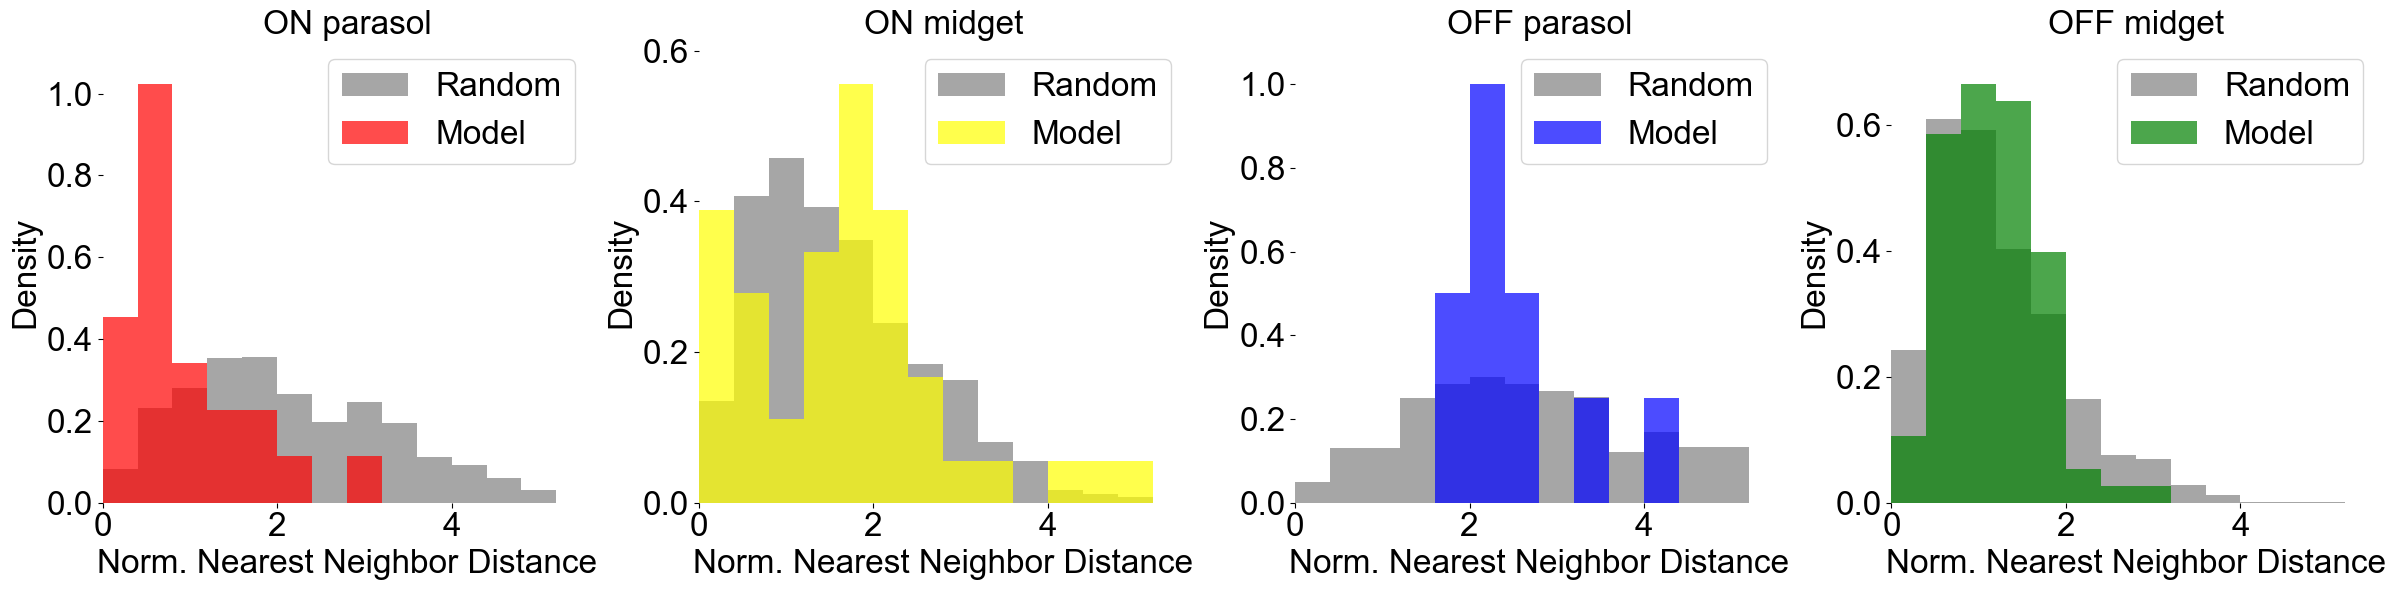


KS Test Results for Each Cell Type:
Cell Type 0: KS Statistic = 0.5427, p-value = 1.5738e-06
Cell Type 2: KS Statistic = 0.2324, p-value = 1.3440e-02
Cell Type 1: KS Statistic = 0.3800, p-value = 8.6146e-02
Cell Type 3: KS Statistic = 0.4740, p-value = 1.0381e-19


In [23]:
#Plot distributions of mosaic measures for each cell type
#I think this is the final version of the code


# ========== Imports ==========
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, ConnectionPatch, Circle
from scipy.stats import ks_2samp

# ====== Flags =====
doplots = False

# ========== Utility: Compute intersection point on ellipse perimeter ==========
def ellipse_edge_point(x0, y0, sigmax, sigmay, angle_deg, dx, dy):
    norm = np.hypot(dx, dy)  # Normalize direction
    dx /= norm
    dy /= norm
    theta = np.deg2rad(angle_deg)  # Convert angle to radians
    cos_t, sin_t = np.cos(theta), np.sin(theta)

    # Rotate direction vector
    dx_rot = dx * cos_t + dy * sin_t
    dy_rot = -dx * sin_t + dy * cos_t

    # Scale to ellipse edge
    scale = 1 / np.sqrt((dx_rot / sigmax) ** 2 + (dy_rot / sigmay) ** 2)
    return x0 + dx * scale, y0 + dy * scale

# ========== Plot ellipses and compute NNNDs ==========
def plot_mosaic_and_nnnd(cell_type, color, dx_offset, dy_offset, spec, fig, subparams_df, plot=doplots):
    nnnd_list = np.zeros(len(subparams_df))  # Store normalized NNNDs
    ax = None
    if plot:
        ax = plt.Subplot(fig, spec)  # Create subplot only if requested
        fig.add_subplot(ax)

    for i in range(len(subparams_df)):
        # Get coordinates of cell i (flipping y-axis)
        x0 = subparams_df.iloc[i]["x0"]
        y0 = 20 - subparams_df.iloc[i]["y0"]

        # Compute Euclidean distance to all other cells
        dists = [np.hypot(subparams_df.iloc[j]["x0"] - x0,
                          20 - subparams_df.iloc[j]["y0"] - y0) if i != j else np.inf
                 for j in range(len(subparams_df))]

        j_min = np.argmin(dists)  # Find nearest neighbor index

        # Get position of nearest neighbor
        x1 = subparams_df.iloc[j_min]["x0"]
        y1 = 20 - subparams_df.iloc[j_min]["y0"]

        # Get ellipse parameters (sigmas and orientation)
        sigmax0, sigmay0 = subparams_df.iloc[i]["sigmax"], subparams_df.iloc[i]["sigmay"]
        angle0 = -subparams_df.iloc[i]["p"] * 45
        sigmax1, sigmay1 = subparams_df.iloc[j_min]["sigmax"], subparams_df.iloc[j_min]["sigmay"]
        angle1 = -subparams_df.iloc[j_min]["p"] * 45

        # Compute direction vector between centers
        dx_line, dy_line = x1 - x0, y1 - y0

        # Find edge-to-edge contact points
        edge_x0, edge_y0 = ellipse_edge_point(x0, y0, sigmax0 / 2, sigmay0 / 2, angle0, dx_line, dy_line)
        edge_x1, edge_y1 = ellipse_edge_point(x1, y1, sigmax1 / 2, sigmay1 / 2, angle1, -dx_line, -dy_line)

        # Compute distances for normalization
        dist0 = np.hypot(edge_x0 - x0, edge_y0 - y0)
        dist1 = np.hypot(edge_x1 - x1, edge_y1 - y1)
        distel = np.hypot(x1 - x0, y1 - y0)
        nnnd_list[i] = 2 * distel / (dist0 + dist1)

        # Plot ellipses and connectors
        if plot:
            ell0 = Ellipse((x0, y0), width=sigmax0, height=sigmay0, angle=angle0,
                           fc=color, ec="black", linewidth=1.5, alpha=0.7)
            ell1 = Ellipse((x1, y1), width=sigmax1, height=sigmay1, angle=angle1,
                           fc=color, ec="black", linewidth=1.5, alpha=0.7)
            ax.add_patch(ell0)
            ax.add_patch(ell1)

            # Connect cell centers with a line
            line = ConnectionPatch((x0, y0), (x1, y1), coordsA="data", coordsB="data",
                                   axesA=ax, axesB=ax, color="gray")
            ax.add_artist(line)

            # Mark edge points
            ax.add_patch(Circle((edge_x0, edge_y0), radius=0.15, color="gray", zorder=10))
            ax.add_patch(Circle((edge_x1, edge_y1), radius=0.15, color="gray", zorder=10))

    if plot:
        ax.set_xlim(0 + dx_offset, 20 + dx_offset)
        ax.set_ylim(0 + dy_offset, 20 + dy_offset)
        ax.set_xticks([])
        ax.set_yticks([])
        for side in ["left", "right", "bottom", "top"]:
            ax.spines[side].set_visible(False)

    return ax, nnnd_list

# ========== Plot Histogram for a Single Cell Type ==========
def plot_histogram(nnnd_list, color, cell_type, filename):
    plt.figure(figsize=(10, 6))
    bins = np.arange(0, 5.6, 0.4)
    plt.hist(nnnd_list, bins=bins, alpha=0.7, color=color)
    plt.title(f'Histogram of Nearest Neighbor Distance (NNND) for Cell Type {cell_type}')
    plt.xlabel('Nearest Neighbor Distance (NNND)')
    plt.ylabel('Frequency')
    plt.xlim(0, 5.5)
    plt.ylim(0, np.max(np.histogram(nnnd_list, bins=bins)[0]) * 1.1)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig(filename, format="svg", transparent=False, bbox_inches="tight")
    plt.show()


# ========== Real Populations ==========

if doplots:
    fig = plt.figure(figsize=(100, 50))
else:
    fig = None
ax, nnnd_list0 = plot_mosaic_and_nnnd(0, "red", 0, 0, mosaic_spec[0, 1], fig,
                                      rf_query.params_df[rf_query.params_df["type"] == 0])
if doplots:
    fig = plt.figure(figsize=(100, 50))
else:
    fig = None
ax, nnnd_list1 = plot_mosaic_and_nnnd(2, "yellow", 0, 0, mosaic_spec[1, 1], fig,
                                      rf_query.params_df[rf_query.params_df["type"] == 2])
if doplots:
    fig = plt.figure(figsize=(100, 50))
else:
    fig = None
ax, nnnd_list2 = plot_mosaic_and_nnnd(1, "blue", 0, 0, mosaic_spec[2, 1], fig,
                                      rf_query.params_df[rf_query.params_df["type"] == 1])
if doplots:
    fig = plt.figure(figsize=(100, 50))
else:
    fig = None
ax, nnnd_list3 = plot_mosaic_and_nnnd(3, "green", 0, 0, mosaic_spec[3, 1], fig,
                                      rf_query.params_df[rf_query.params_df["type"] == 3])

plt.savefig(f"{root}/figures/fig3/main_nnnd.svg", format="svg", transparent=False, bbox_inches="tight")

if doplots:
    plot_histogram(nnnd_list0, "red", 0, f"{root}/figures/fig3/nnnd_histogram_cell_type_0.svg")
    plot_histogram(nnnd_list1, "yellow", 1, f"{root}/figures/fig3/nnnd_histogram_cell_type_2.svg")
    plot_histogram(nnnd_list2, "blue", 2, f"{root}/figures/fig3/nnnd_histogram_cell_type_1.svg")
    plot_histogram(nnnd_list3, "green", 3, f"{root}/figures/fig3/nnnd_histogram_cell_type_3.svg")

# ========== Fake Populations ==========

import numpy as np
import matplotlib.pyplot as plt

# ========== Fake Populations ==========

def generate_fake_populations_and_compute_nnnds(rf_query, nnnd_list0, nnnd_list1,
                                                nnnd_list2, nnnd_list3, num_iterations=10,
                                                plot=doplots, verbose=False):
    all_cells_df = rf_query.params_df.copy()
    
    # Initialize a dictionary to store fake NNND lists for each cell type
    fake_nnnd_lists_by_type = {ctype: [] for ctype in [0, 2, 1, 3]} 

    # Iterate through fake populations
    print("Sampling fake populations...")
    for iteration in range(num_iterations):
        if verbose:
            print(f"Fake iteration {iteration + 1}")
        
        # Loop through each cell type (0, 2, 1, 3)
        for idx, (ctype, color, dx, dy) in enumerate(zip(
            [0, 2, 1, 3],
            ["red", "yellow", "blue", "green"],
            [0, 0, 0, 0],
            [0, 0, 0, 0]
        )):

            # Get the number of cells for the current cell type in the real population
            num_cells_of_type = len(rf_query.params_df[rf_query.params_df["type"] == ctype])

            # Sample the same number of cells from the fake population (sampling only that type)
            fake_cells_df = all_cells_df.sample(
                num_cells_of_type, replace=True
            )

            # Only plot for the first iteration
            if plot:
                fig = plt.figure(figsize=(100, 50)) if iteration == 0 else None
                doplot = (iteration == 0)
            else:
                fig = None
                doplot = False

            # Plot the mosaic for the current iteration and type
            ax, nnnds = plot_mosaic_and_nnnd(
                ctype, color, dx, dy, mosaic_spec[idx, 1],
                fig, fake_cells_df, plot=doplot
            )
            
            #if ax is not None:  # Make sure ax is valid
                # Append each NNND value to the list for the current cell type
            fake_nnnd_lists_by_type[ctype].extend(nnnds)

    # Flatten them to get combined distributions
    fake_nnnd_lists_flat = {ctype: np.array(fake_nnnd_lists_by_type[ctype]) for ctype in fake_nnnd_lists_by_type}

    
    # Check sizes to confirm accumulation over iterations
    fake_counts_flat = {ctype: len(arr) for ctype, arr in fake_nnnd_lists_flat.items()}
    if verbose:
        print(fake_counts_flat)

    # ========== Plot Separate Histograms for Each Cell Type and KS Test ==========
    
    # Cell type list
    cell_types = ["ON parasol", "ON midget", "OFF parasol", "OFF midget"]

    # Store KS test results
    ks_test_results = {}

    # Create a single row of subplots (1 row, 4 columns)
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))  # Adjust the size of the figure here
    
    # Loop through each cell type (0, 2, 1, 3)
    for idx, (ctype, color, real_nnnd_list) in enumerate(zip([0, 2, 1, 3], ["red", "yellow", "blue", "green"], [nnnd_list0, nnnd_list1, nnnd_list2, nnnd_list3])):
        # Get the NNND list for the fake population of the current cell type
        fake_nnnd_list = fake_nnnd_lists_flat[ctype]  # Now we have separate NNND lists for each type
        
        # Perform the Kolmogorov-Smirnov test
        ks_statistic, p_value = ks_2samp(real_nnnd_list, fake_nnnd_list)
        
        # Store the KS test result
        ks_test_results[ctype] = {'ks_statistic': ks_statistic, 'p_value': p_value}
        
        # Print the KS test result for each cell type
        if verbose:
            print(f"KS Test for Cell Type {ctype}: KS Statistic = {ks_statistic:.4f}, p-value = {p_value:.4e}")

        # Plot histogram for real population (on top of fake histogram)
        ax = axes[idx]  # Get the corresponding axis for this cell type
        bins = np.arange(0, 5.6, 0.4)
        
        # Plot the fake population first (as a histogram)
        n_fake, bins_fake, _ = ax.hist(fake_nnnd_list, bins=bins, alpha=0.7, color="gray",
                                       label="Random", density=True)
        
        # Plot the real population's histogram (on top)
        n_real, bins_real, _ = ax.hist(real_nnnd_list, bins=bins_fake, alpha=0.7, color=color,
                                       label="Model", density=True)
        
        ax.set_title(f'{cell_types[idx]}', fontsize=24)  # Increase font size for title
        ax.set_xlabel('Norm. Nearest Neighbor Distance', fontsize=24)  # Increase font size for x-label
        ax.set_ylabel('Density', fontsize=24)  # Increase font size for y-label
        ax.set_xlim(0, 5.6)
        ax.set_ylim(0, np.max([n_fake.max(), n_real.max()]) * 1.1)  # Fix Y-axis scale to match both histograms
        ax.grid(False)  # Remove grid
        ax.set_frame_on(False)  # Remove axes box
        ax.legend(fontsize=24)  # Increase font size for legend
        ax.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for ticks
    
    # Adjust layout so plots don't overlap

    plt.tight_layout()
    plt.savefig(f"{root}/figures/fig3/nnnd_histograms_row.png", format="png", transparent=False,
                bbox_inches="tight")
    plt.show()#figure size things somehow around here
    
    # Return the KS test results
    return ks_test_results



# Run the simulation and plot the histograms with KS test
ks_test_results = generate_fake_populations_and_compute_nnnds(rf_query, nnnd_list0, nnnd_list1,
                                                              nnnd_list2, nnnd_list3, num_iterations=100)

# Optionally, print the KS test results in a more readable format
print("\nKS Test Results for Each Cell Type:")
for ctype, results in ks_test_results.items():
    print(f"Cell Type {ctype}: KS Statistic = {results['ks_statistic']:.4f}, p-value = {results['p_value']:.4e}")

## Cell counts

In [10]:
def plot_counts(left_name, right_name, left_count, right_count, ax):
    sns.barplot(pd.DataFrame({left_name: [left_count], right_name: [right_count]}), ax=ax)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    labelsize = 30
    ax.set_ylim([0, 150])
    ax.xaxis.set_tick_params(width=3, labelsize=labelsize, pad=0)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=labelsize, rotation=45, ha="right")
    ax.yaxis.set_tick_params(width=3, labelsize=labelsize)

/tmp/ipykernel_816847/1158759625.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=labelsize, rotation=45, ha="right")
/tmp/ipykernel_816847/1158759625.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=labelsize, rotation=45, ha="right")


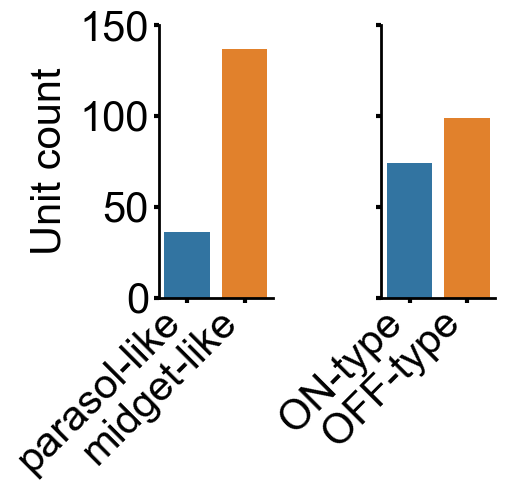

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(5, 5), sharey=True)

midget_count = rf_query.params_df["type"].isin([2, 3]).sum()
parasol_count = rf_query.params_df["type"].isin([0, 1]).sum()
plot_counts("parasol-like", "midget-like", parasol_count, midget_count, axs[0])

on_count = rf_query.params_df["type"].isin([0, 2]).sum()
off_count = rf_query.params_df["type"].isin([1, 3]).sum()
plot_counts("ON-type", "OFF-type", on_count, off_count, axs[1])
labelsize = 30
axs[0].set_ylabel("Unit count", fontsize=labelsize, labelpad=8)
fig.tight_layout()
plt.savefig(f"{root}/figures/fig3/unit_counts.svg", format="svg", transparent=False, bbox_inches="tight")

## Membrane time constant distribution

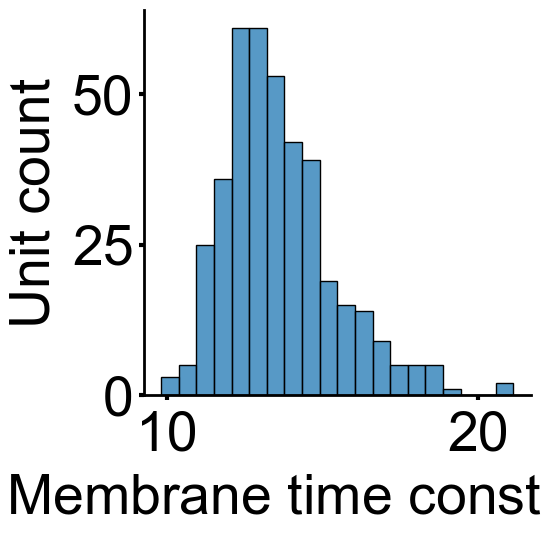

In [12]:
def plot_mem_distribution(time_constants, ax):
    sns.histplot(time_constants, ax=ax)
    
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    labelsize = 40
    ax.xaxis.set_tick_params(width=3, labelsize=labelsize, pad=8)
    ax.yaxis.set_tick_params(width=3, labelsize=labelsize)
    ax.set_xlabel("Membrane time constant $\\tau$", fontsize=labelsize, labelpad=8)
    ax.set_ylabel("Unit count", fontsize=labelsize, labelpad=8)
    
dt = 1000/240
time_constants = -dt / np.log(model._neurons.beta.cpu().detach())
    
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plot_mem_distribution(time_constants, ax)
plt.savefig(f"{root}/figures/fig3/mem_dist.svg", format="svg", transparent=False, bbox_inches="tight")